# **Machine** **Learning**

In [ ]:
!pip install tensorflow keras matplotlib seaborn pandas scikit-learn

In [ ]:
# 1. Basic & Data Handling Libraries
import numpy as np
import pandas as pd

# 2. Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Data Preprocessing, Splitting & Scaling Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 4. Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df=pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

In [ ]:
df.shape

(299, 13)

In [ ]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# **EDA**

In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
continuous_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

zero_counts =(df[continuous_cols]==0).sum

print("=== Check for Invalid Zeros in Continuous Features ===")
print(zero_counts)

=== Check for Invalid Zeros in Continuous Features ===
<bound method DataFrame.sum of        age  creatinine_phosphokinase  ...  serum_sodium   time
0    False                     False  ...         False  False
1    False                     False  ...         False  False
2    False                     False  ...         False  False
3    False                     False  ...         False  False
4    False                     False  ...         False  False
..     ...                       ...  ...           ...    ...
294  False                     False  ...         False  False
295  False                     False  ...         False  False
296  False                     False  ...         False  False
297  False                     False  ...         False  False
298  False                     False  ...         False  False

[299 rows x 7 columns]>


# **Visualization**

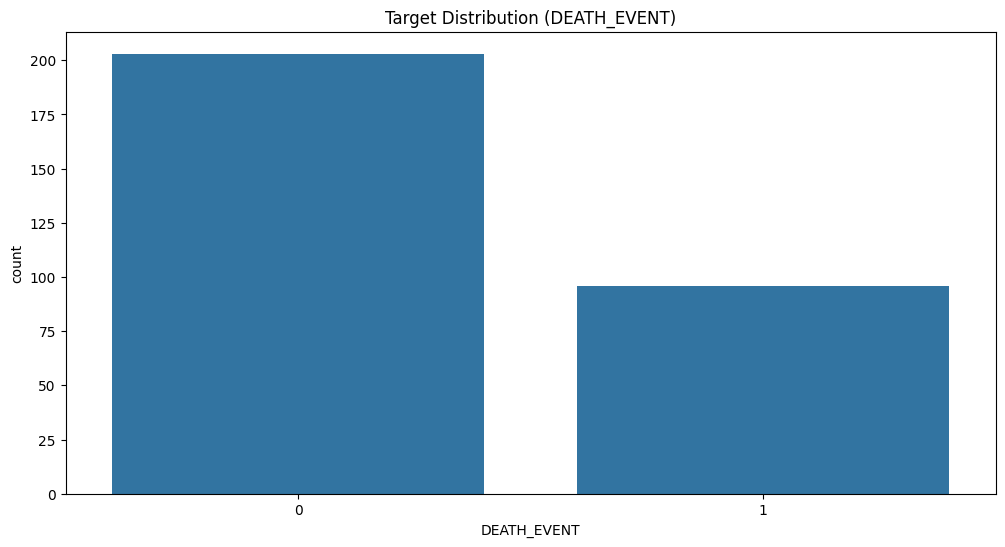

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Target Distribution (DEATH_EVENT)')
plt.show()

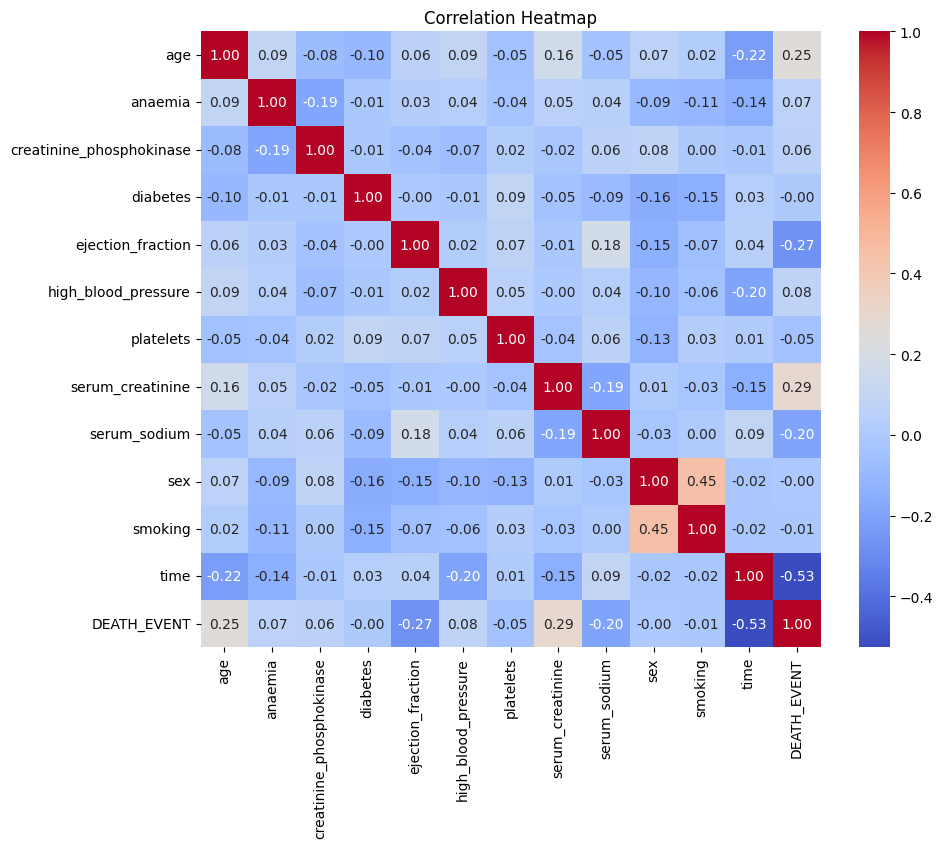

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

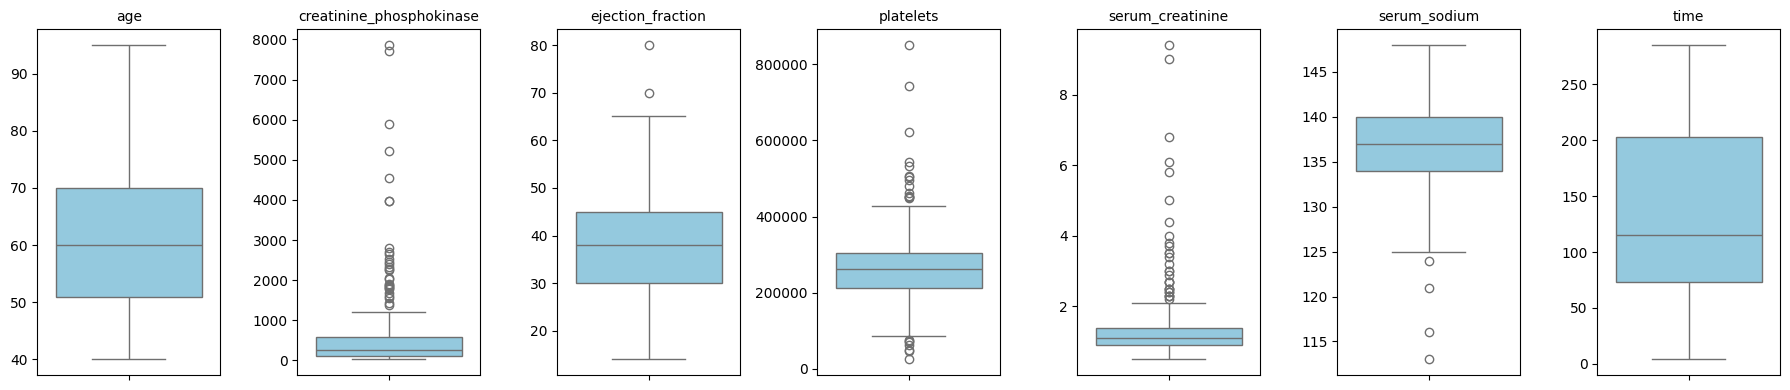

In [ ]:
continuous_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

plt.figure(figsize=(18, 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.show()

# **PreProcessing**

1-**SPLIT**

In [ ]:
X=df.drop('DEATH_EVENT',axis=1)
y=df['DEATH_EVENT']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2-SCALE

In [ ]:
continuous_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

3-MODELING

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 40)

=== Logistic Regression ===
Accuracy: 0.8166666666666667
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60

----------------------------------------
=== Decision Tree ===
Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.60      0.47      0.53        19

    accuracy                           0.73        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.72      0.73      0.72        60

----------------------------------------
=== Random Forest ===
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       

In [ ]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'Bagging': BaggingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 40)

=== Bagging ===
Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        41
           1       0.71      0.53      0.61        19

    accuracy                           0.78        60
   macro avg       0.76      0.71      0.73        60
weighted avg       0.78      0.78      0.77        60

----------------------------------------
=== AdaBoost ===
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.80      0.95      0.87        41
           1       0.82      0.47      0.60        19

    accuracy                           0.80        60
   macro avg       0.81      0.71      0.73        60
weighted avg       0.80      0.80      0.78        60

----------------------------------------
=== Gradient Boosting ===
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80 

# Best **Modeling**

RANDOM FOREST

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%\n")

print("Note: Random Forest achieves the same accuracy as Gradient Boosting (83.33%).")
print("However, Random Forest was selected as the best model due to its high stability, lower risk of overfitting on small clinical datasets, and better generalizability.\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 83.33%

Note: Random Forest achieves the same accuracy as Gradient Boosting (83.33%).
However, Random Forest was selected as the best model due to its high stability, lower risk of overfitting on small clinical datasets, and better generalizability.

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



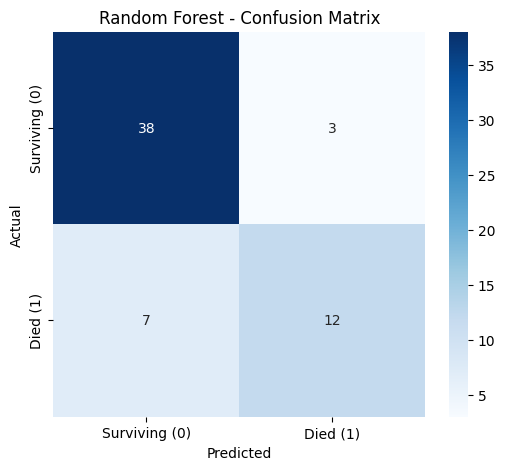

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Surviving (0)', 'Died (1)'],
            yticklabels=['Surviving (0)', 'Died (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()


Features Importances Having The Most Effect On Accuracy: 



/tmp/ipykernel_2976/2799391486.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


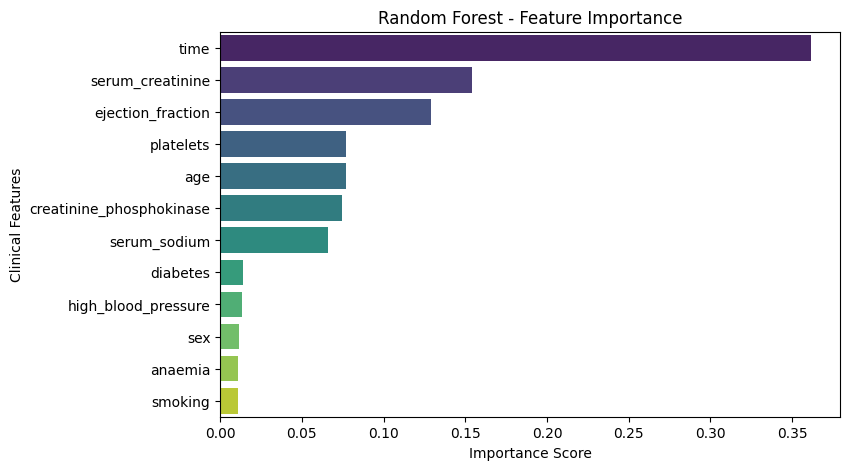

In [ ]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('Features Importances Having The Most Effect On Accuracy: \n')

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Features')
plt.show()

In [ ]:
Comparison_data = {
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'KNN',
        'SVM',
        'Naive Bayes',
        'AdaBoost',
        'Gradient Boosting',
        'XGBoost',
        'Random Forest (Best)',
        'Bagging'
    ],
    'Accuracy (%)': [
        81.66,
        73.33,
        71.66,
        76.66,
        70.00,
        80.00,
        83.33,
        81.66,
        83.33,
        78.33
    ]

}

comparison_df = pd.DataFrame(Comparison_data).sort_values(by='Accuracy (%)',ascending=False)

print("=== Machine Learning Models Performance Comparison ===\n")
print(comparison_df.to_string(index=False))

=== Machine Learning Models Performance Comparison ===

               Model  Accuracy (%)
Random Forest (Best)         83.33
   Gradient Boosting         83.33
 Logistic Regression         81.66
             XGBoost         81.66
            AdaBoost         80.00
                 SVM         76.66
       Decision Tree         73.33
                 KNN         71.66
         Naive Bayes         70.00


# **Deep** **Learning**

**ANN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
tf.random.set_seed(42)

ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
print("Training Neural Network Model...")
history = ann_model.fit(
    X_train_scaled,y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Training Neural Network Model...
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6283 - loss: 0.6342 - val_accuracy: 0.7083 - val_loss: 0.6073
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7120 - loss: 0.6106 - val_accuracy: 0.7083 - val_loss: 0.5805
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7382 - loss: 0.5673 - val_accuracy: 0.7083 - val_loss: 0.5597
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7749 - loss: 0.5448 - val_accuracy: 0.7083 - val_loss: 0.5433
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8063 - loss: 0.5373 - val_accuracy: 0.7292 - val_loss: 0.5269
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8220 - loss: 0.4890 - val_accuracy: 0.7500 - val_loss: 0.5132
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8115 - loss: 0.5161 - val_accuracy: 0.7500 - val_loss: 0.5025
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7906 

# **EVALUATION**

In [ ]:
loss, ann_acc = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nANN Test Accuracy: {ann_acc * 100:.2f}%\n")


ANN Test Accuracy: 85.00%



**VISUALIZATION** **LOSS**

**VISUALIZATION** **ACCURACY**

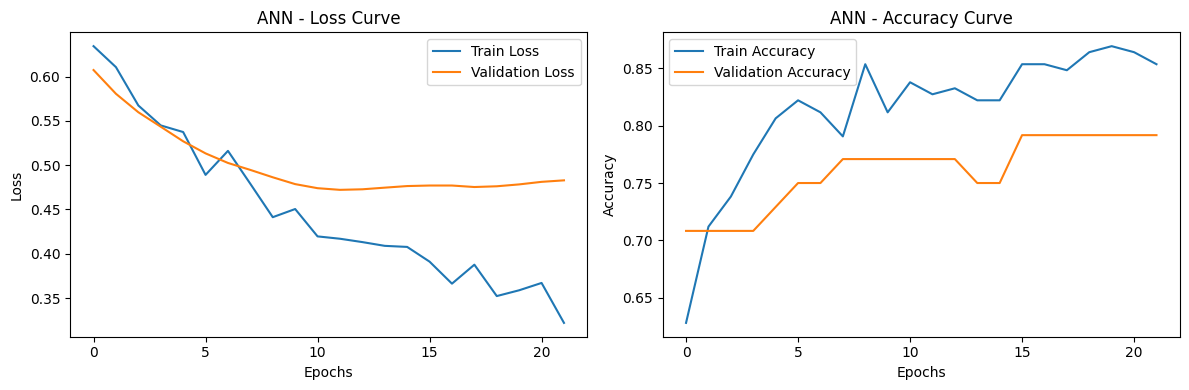

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()